In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

prices = yf.download(
    tickers,
    period="1y",
    auto_adjust=True,
    progress=False
)["Close"]

display(prices.head())

Ticker,AAPL,BLK,GS,JPM,MSFT
Date,,,,,
2025-09-22,255.137497,1112.436523,790.021545,306.574982,510.251892
2025-09-23,253.493591,1108.069946,790.766968,306.869385,505.074432
2025-09-24,251.381409,1104.378906,777.144897,307.536621,505.986877
2025-09-25,255.924606,1123.284912,779.429932,307.566071,502.892365
2025-09-26,254.519806,1132.253052,787.030457,310.127014,507.286194


In [31]:
returns = prices.pct_change().dropna()

display(returns.head())

Ticker,AAPL,BLK,GS,JPM,MSFT
Date,,,,,
2025-09-23,-0.006443,-0.003925,0.000944,0.000960,-0.010147
2025-09-24,-0.008332,-0.003331,-0.017226,0.002174,0.001807
2025-09-25,0.018073,0.017119,0.002940,0.000096,-0.006116
2025-09-26,-0.005489,0.007984,0.009751,0.008326,0.008737
2025-09-29,-0.004032,0.016525,0.002006,-0.001171,0.006139


In [32]:
correlation = returns.corr()

display(correlation.round(2))

Ticker,AAPL,BLK,GS,JPM,MSFT
Ticker,,,,,
AAPL,1.00,0.29,0.22,0.18,0.13
BLK,0.29,1.00,0.54,0.47,0.20
GS,0.22,0.54,1.00,0.63,0.15
JPM,0.18,0.47,0.63,1.00,0.07
MSFT,0.13,0.20,0.15,0.07,1.00


In [33]:
annual_covariance = returns.cov() * 252

display(annual_covariance.round(4))

Ticker,AAPL,BLK,GS,JPM,MSFT
Ticker,,,,,
AAPL,0.0601,0.0193,0.0173,0.0097,0.0100
BLK,0.0193,0.0753,0.0473,0.0287,0.0182
GS,0.0173,0.0473,0.1031,0.0452,0.0159
JPM,0.0097,0.0287,0.0452,0.0500,0.0053
MSFT,0.0100,0.0182,0.0159,0.0053,0.1060


In [34]:
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])

# Ensure weights match the stock-column order
weights = pd.Series(
    {
        "AAPL": 0.25,
        "MSFT": 0.25,
        "JPM": 0.20,
        "GS": 0.15,
        "BLK": 0.15
    }
).reindex(returns.columns)

portfolio_variance = (
    weights.to_numpy()
    @ annual_covariance.to_numpy()
    @ weights.to_numpy()
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Annualized Portfolio Volatility: {portfolio_volatility:.2%}")

Annualized Portfolio Volatility: 17.61%


In [35]:
weights = np.array([0.25, 0.25, 0.20, 0.15, 0.15])

# Ensure weights match the stock-column order
weights = pd.Series(
    {
        "AAPL": 0.25,
        "MSFT": 0.25,
        "JPM": 0.20,
        "GS": 0.15,
        "BLK": 0.15
    }
).reindex(returns.columns)

portfolio_variance = (
    weights.to_numpy()
    @ annual_covariance.to_numpy()
    @ weights.to_numpy()
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Annualized Portfolio Volatility: {portfolio_volatility:.2%}")

Annualized Portfolio Volatility: 17.61%


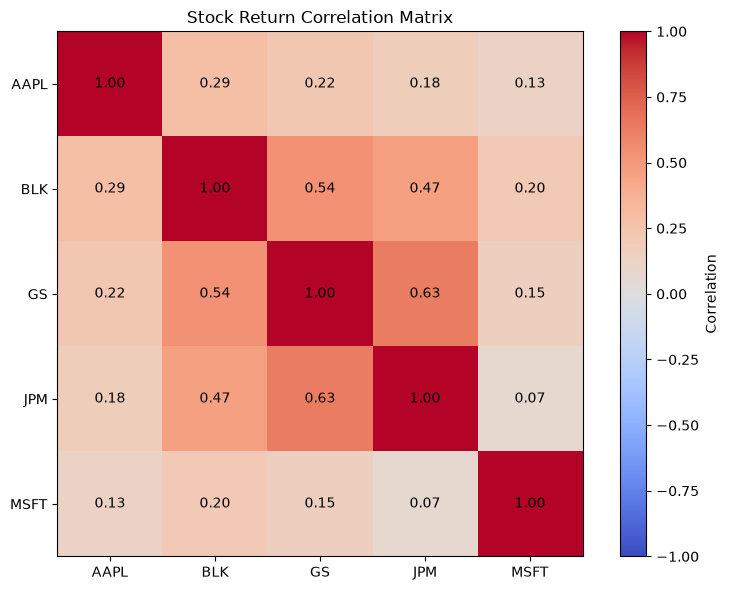

In [36]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation)), correlation.columns)
plt.yticks(range(len(correlation)), correlation.index)

for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Stock Return Correlation Matrix")
plt.tight_layout()
plt.show()

In [37]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

prices = yf.download(
    tickers,
    period="1y",
    auto_adjust=True,
    progress=False
)["Close"]

# Arrange the columns in our chosen order
prices = prices[tickers]

display(prices.head())

Ticker,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2025-09-22,255.137512,510.251892,306.574982,790.021606,1112.436646
2025-09-23,253.493607,505.074432,306.869324,790.766968,1108.069946
2025-09-24,251.381393,505.986908,307.536591,777.144897,1104.378906
2025-09-25,255.924606,502.892365,307.566040,779.429932,1123.284912
2025-09-26,254.519806,507.286194,310.127045,787.030518,1132.253052


In [38]:
returns = prices.pct_change().dropna()

display((returns.head() * 100).round(2))

Ticker,AAPL,MSFT,JPM,GS,BLK
Date,,,,,
2025-09-23,-0.64,-1.01,0.10,0.09,-0.39
2025-09-24,-0.83,0.18,0.22,-1.72,-0.33
2025-09-25,1.81,-0.61,0.01,0.29,1.71
2025-09-26,-0.55,0.87,0.83,0.98,0.80
2025-09-29,-0.40,0.61,-0.12,0.20,1.65


In [39]:
correlation = returns.corr()

display(correlation.round(2))

Ticker,AAPL,MSFT,JPM,GS,BLK
Ticker,,,,,
AAPL,1.00,0.13,0.18,0.22,0.29
MSFT,0.13,1.00,0.07,0.15,0.20
JPM,0.18,0.07,1.00,0.63,0.47
GS,0.22,0.15,0.63,1.00,0.54
BLK,0.29,0.20,0.47,0.54,1.00


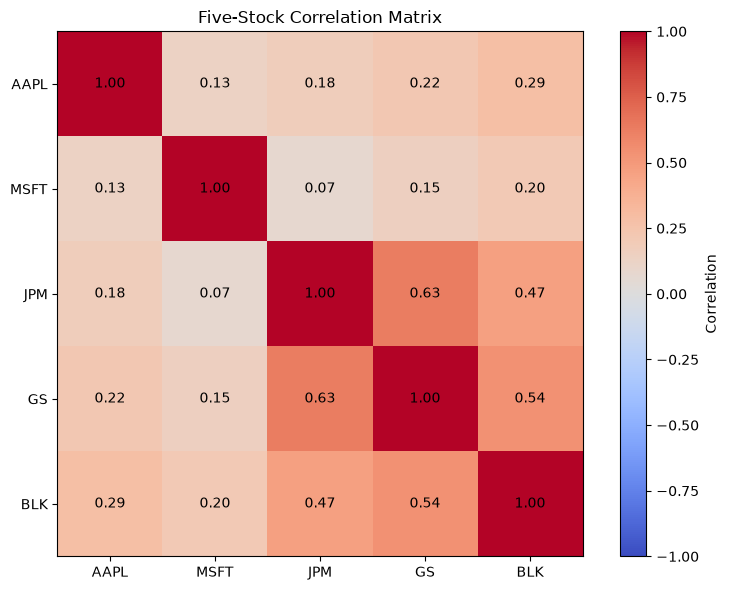

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation)), correlation.columns)
plt.yticks(range(len(correlation)), correlation.index)

for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Five-Stock Correlation Matrix")
plt.tight_layout()
plt.show()

In [41]:
import numpy as np
import pandas as pd

# Annualize the covariance matrix
annual_covariance = returns.cov() * 252

# Portfolio weights, aligned with the stock columns
weights = pd.Series({
    "AAPL": 0.25,
    "MSFT": 0.25,
    "JPM": 0.20,
    "GS": 0.15,
    "BLK": 0.15
}).reindex(returns.columns)

# Calculate portfolio variance and volatility
portfolio_variance = (
    weights.to_numpy()
    @ annual_covariance.to_numpy()
    @ weights.to_numpy()
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Annualized Portfolio Volatility: {portfolio_volatility:.2%}")


Annualized Portfolio Volatility: 17.61%


In [42]:
stock_volatility = returns.std() * np.sqrt(252)

comparison = pd.DataFrame({
    "Annualized Volatility (%)": stock_volatility * 100
})

display(comparison.round(2))

print(f"Portfolio Volatility: {portfolio_volatility:.2%}")

,Annualized Volatility (%)
Ticker,
AAPL,24.51
MSFT,32.55
JPM,22.36
GS,32.11
BLK,27.45


Portfolio Volatility: 17.61%


In [43]:
# Weighted average volatility of individual holdings
weighted_volatility = (
    weights * stock_volatility
).sum()

# Difference between weighted volatility and portfolio volatility
diversification_benefit = (
    weighted_volatility - portfolio_volatility
)

print(f"Weighted Average Stock Volatility: {weighted_volatility:.2%}")
print(f"Actual Portfolio Volatility: {portfolio_volatility:.2%}")
print(f"Diversification Benefit: {diversification_benefit:.2%}")

Weighted Average Stock Volatility: 27.67%
Actual Portfolio Volatility: 17.61%
Diversification Benefit: 10.06%
